In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv(
    "../data/SPY_market_data.csv",
    index_col=0,
    parse_dates=True
)

data.head()

C:\Users\panos\AppData\Local\Temp\ipykernel_23312\869479044.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv(


,Close,High,Low,Open,Volume
Price,,,,,
Ticker,SPY,SPY,SPY,SPY,SPY
Date,NaN,NaN,NaN,NaN,NaN
2010-01-04,84.57847595214844,84.62325228661169,83.22020543300488,83.8620261315511,118944600
2010-01-05,84.8023681640625,84.83968557413895,84.22025300742887,84.52623982731122,111579900
2010-01-06,84.862060546875,85.0710243456003,84.6530967481497,84.72026124323862,116074400


In [3]:
data.info()

<class 'pandas.DataFrame'>
Index: 4026 entries, Ticker to 2025-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Close   4025 non-null   str  
 1   High    4025 non-null   str  
 2   Low     4025 non-null   str  
 3   Open    4025 non-null   str  
 4   Volume  4025 non-null   str  
dtypes: str(5)
memory usage: 536.7 KB


In [4]:
data.describe()

,Close,High,Low,Open,Volume
count,4025,4025,4025,4025,4025
unique,3943,4023,4025,4025,4022
top,111.46190643310547,184.95531252922103,SPY,SPY,89351900
freq,3,2,1,1,2


In [7]:
data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')

In [8]:
data.dtypes

Close     str
High      str
Low       str
Open      str
Volume    str
dtype: object

In [9]:
numeric_columns = [
    "Close",
    "High",
    "Low",
    "Open",
    "Volume"
]

for col in numeric_columns:
    data[col] = pd.to_numeric(
        data[col],
        errors="coerce"
    )

In [10]:
### Calculation of Returns
data["Returns"] = np.log(
    data["Close"] /
    data["Close"].shift(1)
)

data.dropna(inplace=True)

data.head()

,Close,High,Low,Open,Volume,Returns
Price,,,,,,
2010-01-05,84.802368,84.839686,84.220253,84.526240,111579900.0,0.002644
2010-01-06,84.862061,85.071024,84.653097,84.720261,116074400.0,0.000704
2010-01-07,85.220322,85.324804,84.466554,84.705371,131091100.0,0.004213
2010-01-08,85.503891,85.541208,84.824759,84.996405,126402800.0,0.003322
2010-01-11,85.623299,85.921815,85.257606,85.884503,106375700.0,0.001396


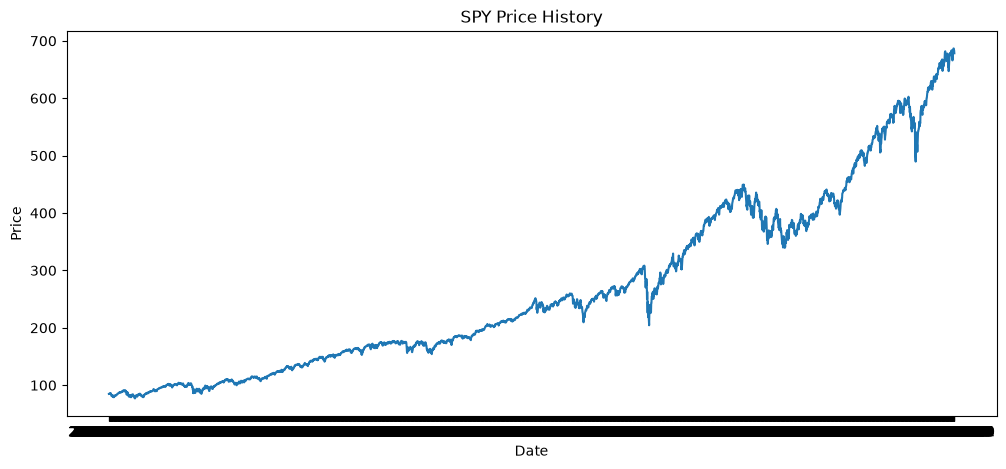

In [11]:
#### Price Chart
plt.figure(figsize=(12,5))

plt.plot(
    data.index,
    data["Close"]
)

plt.title("SPY Price History")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

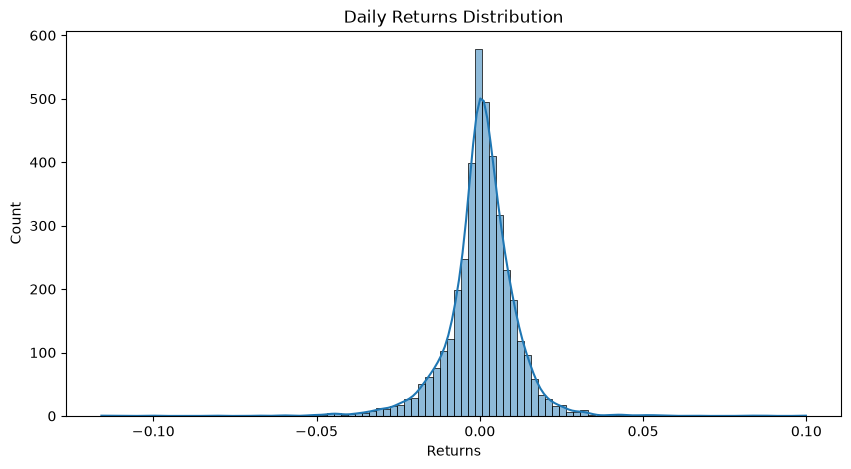

In [12]:
#### Return Distribution
plt.figure(figsize=(10,5))

sns.histplot(
    data["Returns"],
    bins=100,
    kde=True
)

plt.title("Daily Returns Distribution")

plt.show()

In [13]:
###### Rolling Volatility
data["Rolling_Volatility"] = (
    data["Returns"]
    .rolling(30)
    .std()
    *
    np.sqrt(252)
)

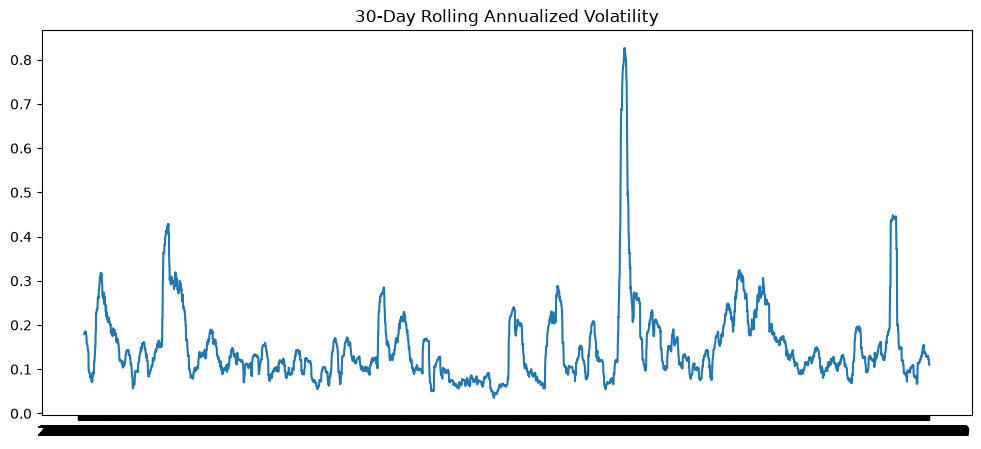

In [14]:
plt.figure(figsize=(12,5))

plt.plot(
    data.index,
    data["Rolling_Volatility"]
)

plt.title(
    "30-Day Rolling Annualized Volatility"
)

plt.show()

In [15]:
data.to_csv(
    "../data/SPY_processed_data.csv"
)

Built a financial data pipeline and performed exploratory analysis on equity market data, including return calculation and volatility analysis.